# MathNet CNN Math Problem Detection & Understanding
Uses the `ShadenA/MathNet` dataset with a CNN-based classifier to categorize math problems by topic.

## 1. Install Dependencies

In [12]:
!pip install tensorflow keras matplotlib scikit-learn seaborn pandas numpy pyarrow

## 2. Load the Dataset

In [13]:
import os

if not os.path.exists("MathNet"):
    !git lfs install
    !git clone https://huggingface.co/datasets/ShadenA/MathNet
    print("MathNet cloned successfully.")
else:
    print("MathNet directory already exists — skipping clone.")

MathNet directory already exists — skipping clone.


In [ ]:
import pandas as pd
import glob
import os
import io
from PIL import Image
from concurrent.futures import ThreadPoolExecutor

files = sorted(glob.glob("MathNet/data/all/train-*.parquet"))
N_WORKERS = min(os.cpu_count(), len(files))
print(f"Loading {len(files)} parquet files with {N_WORKERS} workers...")

with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    dfs = list(pool.map(pd.read_parquet, files))

df_full = pd.concat(dfs, ignore_index=True)
print(f"Total rows loaded: {len(df_full):,}")
print("Columns:", df_full.columns.tolist())

# Scan every row to find those with at least one decodable image
def has_valid_image(imgs):
    if not isinstance(imgs, list) or len(imgs) == 0:
        return False
    for entry in imgs:
        if entry is not None and isinstance(entry, dict) and entry.get("bytes"):
            try:
                Image.open(io.BytesIO(entry["bytes"]))
                return True
            except Exception:
                pass
    return False

print("\nScanning for rows with valid images across all countries (may take ~1–2 min)...")
image_mask = df_full["images"].apply(has_valid_image)
df_train = df_full[image_mask].reset_index(drop=True)

print(f"\nRows with valid images: {len(df_train):,} / {len(df_full):,}")
print("\nBreakdown by country:")
print(df_train["country"].value_counts().to_string())
print("\nExample entry:")
print(df_train.iloc[0])

Rows per country:
country
United States    4819


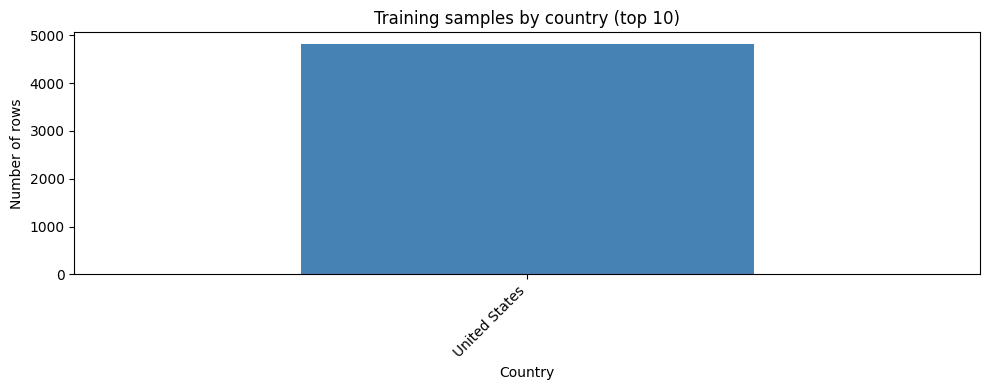

In [15]:
# import matplotlib.pyplot as plt

# if "country" in df_train.columns:
#     country_counts = df_train["country"].value_counts()
#     print("Rows per country:")
#     print(country_counts.to_string())

#     plt.figure(figsize=(10, 4))
#     country_counts.plot(kind="bar", color="steelblue")
#     plt.title("Training samples by country (top 10)")
#     plt.xlabel("Country")
#     plt.ylabel("Number of rows")
#     plt.xticks(rotation=45, ha="right")
#     plt.tight_layout()
#     plt.show()
# else:
#     print("No 'country' column in dataset.")

## 3. Explore the Dataset

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Columns:", df_train.columns.tolist())
print("Shape:", df_train.shape)
df_train.head()

Columns: ['id', 'problem_markdown', 'solutions_markdown', 'images', 'country', 'competition', 'topics_flat', 'language', 'problem_type', 'final_answer']
Shape: (4819, 10)


,id,problem_markdown,solutions_markdown,images,country,competition,topics_flat,language,problem_type,final_answer
0,0hsp,Problem:\n\nLet $D$ be a dodecahedron which ca...,[Solution:\n\n$D$ has the greater volume.\n\nT...,[{'bytes': b'\xff\xd8\xff\xdb\x00\x84\x00\x08\...,United States,None,"[Geometry > Solid Geometry > Volume, Geometry ...",None,proof and answer,The dodecahedron has the greater volume.
1,0k0l,Problem:\n\nTwo three-dimensional objects are ...,[Solution:\n\nThere are nine non-equivalent co...,[{'bytes': b'\xff\xd8\xff\xdb\x00\x84\x00\x08\...,United States,19th Bay Area Mathematical Olympiad,[Discrete Mathematics > Combinatorics > Enumer...,None,proof and answer,9
2,0kq5,Problem:\n\nIn convex quadrilateral $ABCD$ wit...,[Solution:\n\nEvidently $ABCD$ is an isosceles...,[],United States,HMMT November 2022,[Geometry > Plane Geometry > Transformations >...,None,final answer only,7
3,0hpb,Problem:\n\nA natural number $n$ is chosen bet...,[Solution:\n\nLet $n-k = x^{2}$ and $n+\ell = ...,[],United States,Berkeley Math Circle Monthly Contest 4,[Algebra > Prealgebra / Basic Algebra > Intege...,None,proof only,None
4,0ijk,Find all positive integers $n$ such that there...,[The answer is $n = 4$ or $n \ge 6$.\n\nI. Fir...,[],United States,USAMO,[Algebra > Equations and Inequalities > QM-AM-...,None,proof and answer,n = 4 or n ≥ 6


Using label column: topics_flat
Counted 2509 unique categories using 2 workers.


/tmp/ipykernel_27765/1323306223.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


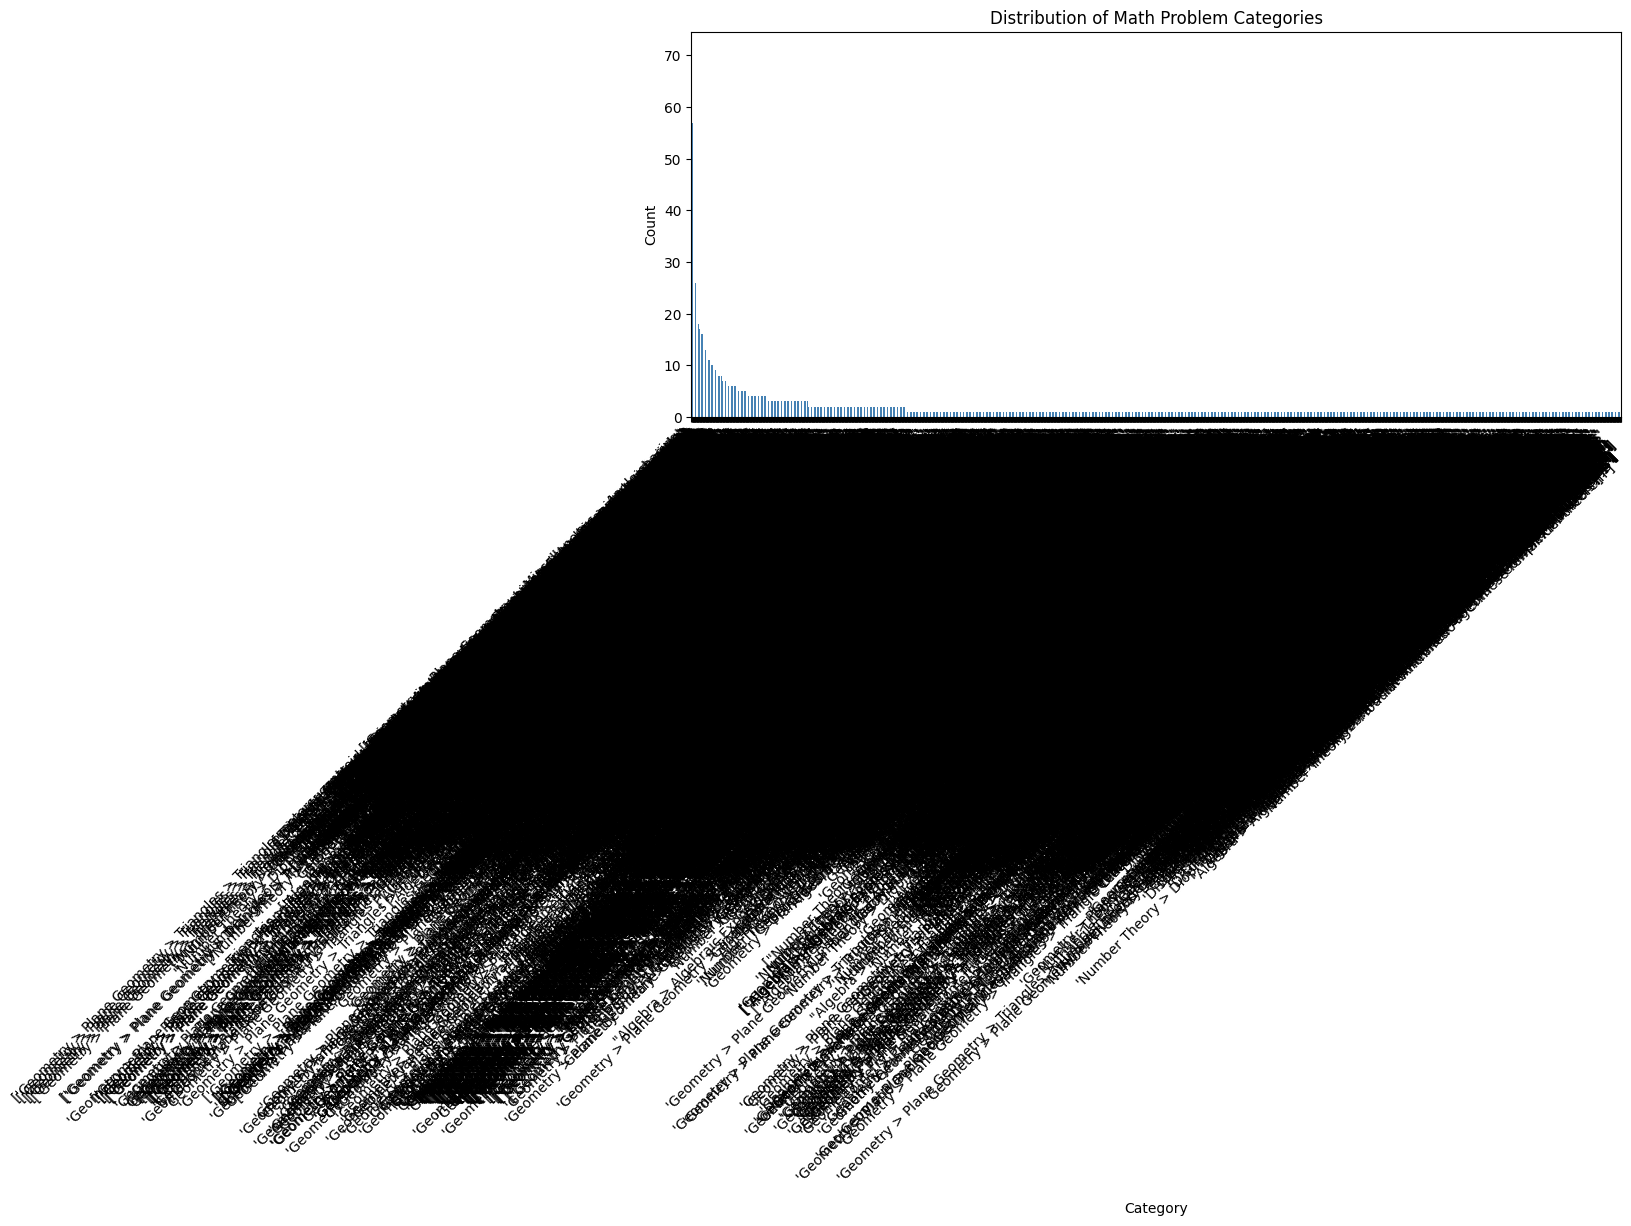

In [17]:
import os
from concurrent.futures import ThreadPoolExecutor
import numpy as np

label_col = "topics_flat"
print("Using label column:", label_col)

# Parallel value_counts — split into pandas Series chunks, count each, then merge
N_WORKERS = min(os.cpu_count(), 8)
series = df_train[label_col].astype(str)
idx_chunks = np.array_split(np.arange(len(series)), N_WORKERS)
chunks = [series.iloc[idx] for idx in idx_chunks]

with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    partial_counts = list(pool.map(lambda c: c.value_counts(), chunks))

label_counts = (
    pd.concat(partial_counts)
    .groupby(level=0)
    .sum()
    .sort_values(ascending=False)
)
print(f"Counted {len(label_counts)} unique categories using {N_WORKERS} workers.")

plt.figure(figsize=(12, 5))
label_counts.plot(kind="bar", color="steelblue")
plt.title("Distribution of Math Problem Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Preprocess â€” Tokenise Text for 1-D CNN

In [ ]:
import ast
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tf_keras.preprocessing.text import Tokenizer
from tf_keras.preprocessing.sequence import pad_sequences

text_col = "problem_markdown"
print("Text column:", text_col, "| Label column:", label_col)

# Extract the top-level topic (e.g. "Geometry" from "Geometry > Solid Geometry > Volume")
def extract_top_label(topics_raw):
    try:
        topics = topics_raw if isinstance(topics_raw, list) else ast.literal_eval(str(topics_raw))
        if topics:
            return topics[0].split(" > ")[0].strip()
    except Exception:
        pass
    return "Unknown"

df_train["label"] = df_train[label_col].apply(extract_top_label)
print("\nTop-level topic distribution:")
print(df_train["label"].value_counts().to_string())

le = LabelEncoder()
y_all = le.fit_transform(df_train["label"])
num_classes = len(le.classes_)
print(f"\nClasses ({num_classes}):", le.classes_)

# Tokenise the problem text
MAX_WORDS = 20_000
MAX_LEN   = 128

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df_train[text_col].astype(str))

X_all = pad_sequences(
    tokenizer.texts_to_sequences(df_train[text_col].astype(str)),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)
print("X shape:", X_all.shape, "| y shape:", y_all.shape)

## 5. Train / Validation Split

In [19]:
from sklearn.model_selection import train_test_split
import numpy as np

class_counts = np.bincount(y_all)

if class_counts.min() >= 2:
    stratify_labels = y_all
    print("Using stratified split.")
else:
    stratify_labels = None
    print("Some classes have only 1 example, so using a regular random split.")

X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=stratify_labels,
)
print("Train:", X_train.shape, "| Val:", X_val.shape)

Some classes have only 1 example, so using a regular random split.
Train: (3855, 128) | Val: (964, 128)


## 5a. Image Data Preparation
The dataset includes problem figures stored as raw bytes. We decode each problem's first image, resize it to 224 × 224 (the standard ImageNet input size), and create a train/val split aligned with the text split.

In [ ]:
import io
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split as _tts
from concurrent.futures import ThreadPoolExecutor

IMG_SIZE = 224

# df_train is already filtered to rows with valid images — no zero fallback needed
def decode_first_image(idx, size=(IMG_SIZE, IMG_SIZE)):
    for entry in df_train.iloc[idx]["images"]:
        if entry is not None and isinstance(entry, dict) and entry.get("bytes"):
            try:
                img = Image.open(io.BytesIO(entry["bytes"])).convert("RGB")
                return np.array(img.resize(size), dtype=np.uint8)
            except Exception:
                pass
    return np.zeros((size[0], size[1], 3), dtype=np.uint8)  # fallback (shouldn't trigger)

N_WORKERS = min(os.cpu_count(), 8)
print(f"Decoding {len(df_train):,} images with {N_WORKERS} workers (may take ~30 s)...")

with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    images = list(pool.map(decode_first_image, range(len(df_train))))

X_images = np.stack(images)
n_with = int((X_images.sum(axis=(1, 2, 3)) > 0).sum())
print(f"Image array shape: {X_images.shape} | dtype: {X_images.dtype}")
print(f"Non-black images: {n_with} / {len(X_images)}")

X_img_train, X_img_val, _, _ = _tts(
    X_images, y_all, test_size=0.2, random_state=42, stratify=stratify_labels
)
print("Image train:", X_img_train.shape, "| val:", X_img_val.shape)

## 5b. Large Pretrained Model — EfficientNetB0 (ImageNet)
EfficientNetB0 is pre-trained on ImageNet (1.4 M images, 1 000 classes). We freeze its convolutional base and attach a small classification head for math-topic prediction from the problem figure.

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre

BATCH_SIZE = 32

def make_eff_dataset(X_imgs, y_labels, batch_size=BATCH_SIZE, training=False):
    """Stream uint8 images and cast to float32 per batch — no full-array copy."""
    def _preprocess(img, label):
        return eff_pre(tf.cast(img, tf.float32)), label

    ds = tf.data.Dataset.from_tensor_slices((X_imgs, y_labels))
    if training:
        ds = ds.shuffle(buffer_size=2048, seed=42)
    ds = ds.batch(batch_size)
    ds = ds.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

eff_train_ds = make_eff_dataset(X_img_train, y_train, training=True)
eff_val_ds   = make_eff_dataset(X_img_val,   y_val,   training=False)
print("EfficientNet tf.data datasets ready (preprocessing happens per batch).")

def build_large_pretrained(num_classes, img_size=IMG_SIZE):
    base = EfficientNetB0(include_top=False, weights="imagenet",
                          input_shape=(img_size, img_size, 3))
    base.trainable = False

    inp = layers.Input(shape=(img_size, img_size, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(256, activation="relu",
                        kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    m = models.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

large_model = build_large_pretrained(num_classes)
large_model.summary()

EfficientNet tf.data datasets ready (preprocessing happens per batch).


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2509)           │       644,813 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,027,440 (19.18 MB)

 Trainable params: 975,309 (3.72 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [22]:
large_history = large_model.fit(
    eff_train_ds,
    validation_data=eff_val_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1),
    ]
)

Epoch 1/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.0042 - loss: 7.8561 - val_accuracy: 0.0124 - val_loss: 7.8476 - learning_rate: 1.0000e-04
Epoch 2/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 337s 3s/step - accuracy: 0.0078 - loss: 7.6320 - val_accuracy: 0.0124 - val_loss: 7.8369 - learning_rate: 1.0000e-04
Epoch 3/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.0114 - loss: 7.4253 - val_accuracy: 0.0124 - val_loss: 7.8281 - learning_rate: 1.0000e-04
Epoch 4/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.0127 - loss: 7.3500 - val_accuracy: 0.0124 - val_loss: 7.8197 - learning_rate: 1.0000e-04
Epoch 5/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 327s 3s/step - accuracy: 0.0119 - loss: 7.3246 - val_accuracy: 0.0124 - val_loss: 7.8153 - learning_rate: 1.0000e-04
Epoch 6/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 320s 3s/step - accuracy: 0.0109 - loss: 7.3008 - val_accuracy: 0.0124 - val_loss: 7.8144 - learning_rate: 1.0000e-04
Epoch 7/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 333s 3s/step - acc

## 5c. Small Pretrained Model — MobileNetV2-0.35 (ImageNet)
MobileNetV2 with `alpha=0.35` is a compact variant (~400 K parameters) built for mobile/edge deployment. Only the new classification head trains; the ImageNet base is frozen.

In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre

def make_mob_dataset(X_imgs, y_labels, batch_size=BATCH_SIZE, training=False):
    """Stream uint8 images and cast to float32 per batch — no full-array copy."""
    def _preprocess(img, label):
        return mob_pre(tf.cast(img, tf.float32)), label

    ds = tf.data.Dataset.from_tensor_slices((X_imgs, y_labels))
    if training:
        ds = ds.shuffle(buffer_size=2048, seed=42)
    ds = ds.batch(batch_size)
    ds = ds.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

mob_train_ds = make_mob_dataset(X_img_train, y_train, training=True)
mob_val_ds   = make_mob_dataset(X_img_val,   y_val,   training=False)
print("MobileNetV2 tf.data datasets ready (preprocessing happens per batch).")

def build_small_pretrained(num_classes, img_size=IMG_SIZE):
    base = MobileNetV2(include_top=False, weights="imagenet",
                       input_shape=(img_size, img_size, 3), alpha=0.35)
    base.trainable = False

    inp = layers.Input(shape=(img_size, img_size, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(128, activation="relu",
                        kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    m = models.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

small_model = build_small_pretrained(num_classes)
small_model.summary()

MobileNetV2 tf.data datasets ready (preprocessing happens per batch).
2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_224            │ (None, 7, 7, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2509)           │       323,661 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 902,957 (3.44 MB)

 Trainable params: 490,189 (1.87 MB)

 Non-trainable params: 412,768 (1.57 MB)

In [24]:
small_history = small_model.fit(
    mob_train_ds,
    validation_data=mob_val_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1),
    ]
)

Epoch 1/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 85s 649ms/step - accuracy: 0.0078 - loss: 7.8444 - val_accuracy: 0.0000e+00 - val_loss: 7.8412 - learning_rate: 1.0000e-04
Epoch 2/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 75s 594ms/step - accuracy: 0.0117 - loss: 7.7856 - val_accuracy: 0.0124 - val_loss: 7.7940 - learning_rate: 1.0000e-04
Epoch 3/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 88s 648ms/step - accuracy: 0.0130 - loss: 7.4114 - val_accuracy: 0.0124 - val_loss: 7.8888 - learning_rate: 1.0000e-04
Epoch 4/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.0136 - loss: 7.2109
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
121/121 ━━━━━━━━━━━━━━━━━━━━ 72s 595ms/step - accuracy: 0.0106 - loss: 7.2309 - val_accuracy: 0.0124 - val_loss: 8.0139 - learning_rate: 1.0000e-04
Epoch 5/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 90s 660ms/step - accuracy: 0.0119 - loss: 7.1991 - val_accuracy: 0.0124 - val_loss: 8.0993 - learning_rate: 5.0000e-05
Epoch 6/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms

## 6. Build the 1-D CNN Model

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

EMBED_DIM = 128

def build_cnn(vocab_size, embed_dim, seq_len, num_classes):
    inp = layers.Input(shape=(seq_len,))

    # Embedding with spatial dropout
    x = layers.Embedding(vocab_size, embed_dim)(inp)
    x = layers.SpatialDropout1D(0.2)(x)

    # Parallel conv branches — kernel sizes 2–7 capture short to long n-gram patterns
    branches = []
    for k in (2, 3, 4, 5, 6, 7):
        b = layers.Conv1D(128, k, activation="relu", padding="same",
                          kernel_regularizer=regularizers.l2(1e-4))(x)
        b = layers.BatchNormalization()(b)
        b = layers.Conv1D(64, k, activation="relu", padding="same",
                          kernel_regularizer=regularizers.l2(1e-4))(b)
        b = layers.BatchNormalization()(b)
        b = layers.GlobalMaxPooling1D()(b)
        branches.append(b)

    # Also add a global average pool branch on the raw embedding for softer context
    avg = layers.GlobalAveragePooling1D()(x)
    branches.append(avg)

    merged = layers.Concatenate()(branches)          # 6*64 + embed_dim = 512-dim

    # Deep classification head
    merged = layers.Dense(512, activation="relu",
                          kernel_regularizer=regularizers.l2(1e-4))(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(0.5)(merged)

    merged = layers.Dense(256, activation="relu",
                          kernel_regularizer=regularizers.l2(1e-4))(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(0.4)(merged)

    merged = layers.Dense(128, activation="relu",
                          kernel_regularizer=regularizers.l2(1e-4))(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Dropout(0.3)(merged)

    merged = layers.Dense(64, activation="relu")(merged)
    merged = layers.Dropout(0.2)(merged)

    out = layers.Dense(num_classes, activation="softmax")(merged)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_cnn(MAX_WORDS, EMBED_DIM, MAX_LEN, num_classes)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 128, 128)  │  2,560,000 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 128, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 128)  │     32,896 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 128)  │     49,280 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 128, 128)  │     65,664 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 128, 128)  │     82,048 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 128, 128)  │     98,432 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 128, 128)  │    114,816 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 64)   │     16,448 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 64)   │     24,640 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 128, 64)   │     32,832 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 128, 64)   │     41,024 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 128, 64)   │     49,216 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,831,117 (14.61 MB)

 Trainable params: 3,827,021 (14.60 MB)

 Non-trainable params: 4,096 (16.00 KB)

## 7. Train

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 74s 976ms/step - accuracy: 5.1881e-04 - loss: 8.0716 - val_accuracy: 0.0021 - val_loss: 8.0392 - learning_rate: 1.0000e-04
Epoch 2/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 60s 973ms/step - accuracy: 0.0023 - loss: 7.9827 - val_accuracy: 0.0021 - val_loss: 8.0217 - learning_rate: 1.0000e-04
Epoch 3/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 81s 964ms/step - accuracy: 0.0062 - loss: 7.9059 - val_accuracy: 0.0083 - val_loss: 8.0219 - learning_rate: 1.0000e-04
Epoch 4/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 876ms/step - accuracy: 0.0097 - loss: 7.8510
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
61/61 ━━━━━━━━━━━━━━━━━━━━ 80s 923ms/step - accuracy: 0.0114 - loss: 7.8432 - val_accuracy: 0.0083 - val_loss: 8.0550 - learning_rate: 1.0000e-04
Epoch 5/60
61/61 ━━━━━━━━━━━━━━━━━━━━ 59s 962ms/step - accuracy: 0.0140 - loss: 7.7943 - val_accuracy: 0.0083 - val_loss: 8.0992 - learning_rate: 5.0000e-05
Epoch 5: early stopping
Restoring model weights from the end

## 7b. All-Model Comparison
Side-by-side parameter count and best validation accuracy for all three models.

                   Model Parameters Best Val Acc
           1D CNN (text)  3,831,117        0.83%
  EfficientNetB0 (image)  5,027,440        1.35%
MobileNetV2-0.35 (image)    902,957        1.24%


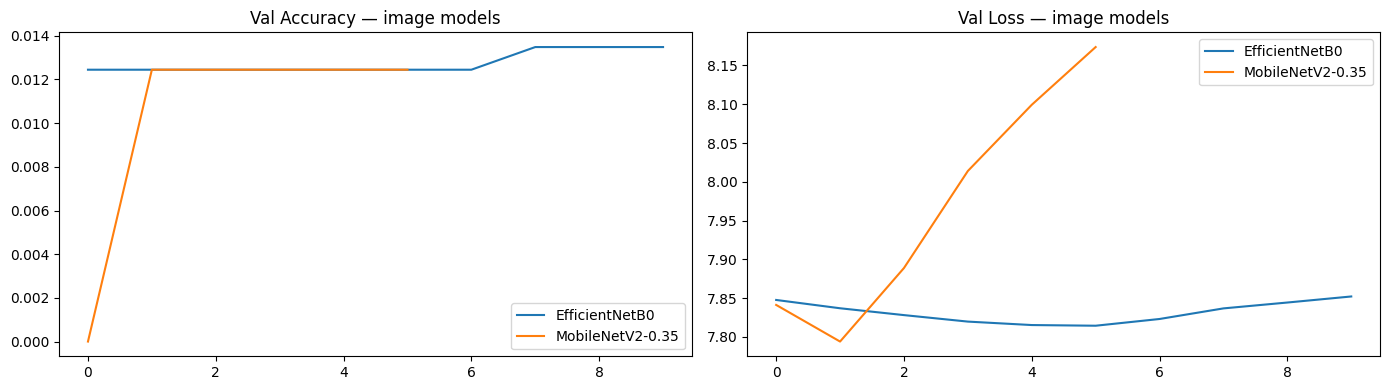

In [27]:
import pandas as pd

def _best_val_acc(hist):
    return max(hist.history["val_accuracy"])

rows = [
    {"Model": "1D CNN (text)",            "Parameters": model.count_params(),       "Best Val Acc": _best_val_acc(history)},
    {"Model": "EfficientNetB0 (image)",   "Parameters": large_model.count_params(), "Best Val Acc": _best_val_acc(large_history)},
    {"Model": "MobileNetV2-0.35 (image)", "Parameters": small_model.count_params(), "Best Val Acc": _best_val_acc(small_history)},
]
df_cmp = pd.DataFrame(rows)
df_cmp["Parameters"]   = df_cmp["Parameters"].map("{:,}".format)
df_cmp["Best Val Acc"] = df_cmp["Best Val Acc"].map("{:.2%}".format)
print(df_cmp.to_string(index=False))

# Training curves for both image models
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for hist, label in [(large_history, "EfficientNetB0"), (small_history, "MobileNetV2-0.35")]:
    axes[0].plot(hist.history["val_accuracy"], label=label)
    axes[1].plot(hist.history["val_loss"],     label=label)
axes[0].set_title("Val Accuracy — image models"); axes[0].legend()
axes[1].set_title("Val Loss — image models");     axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Training Curves

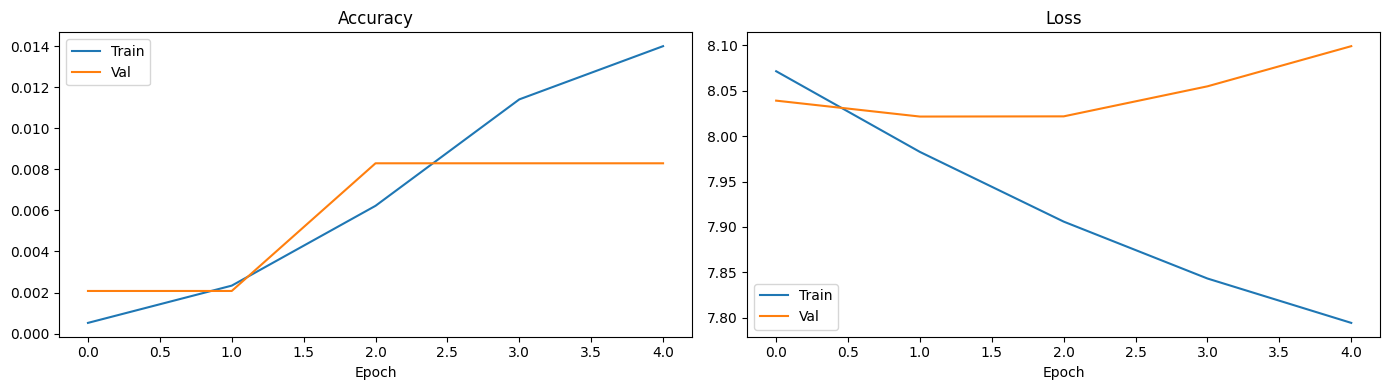

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, title in zip(
    axes,
    [("accuracy", "val_accuracy"), ("loss", "val_loss")],
    ["Accuracy", "Loss"]
):
    ax.plot(history.history[metric[0]], label="Train")
    ax.plot(history.history[metric[1]], label="Val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Evaluation â€” Confusion Matrix & Classification Report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = np.argmax(model.predict(X_val), axis=1)

# Only use labels that appear in val set or predictions
present_labels = np.union1d(np.unique(y_val), np.unique(y_pred))
present_names = le.classes_[present_labels]

print(classification_report(y_val, y_pred, labels=present_labels, target_names=present_names))

cm = confusion_matrix(y_val, y_pred, labels=present_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=present_names, yticklabels=present_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 252ms/step
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         precision    recall  f1-score   support

                                                                                                                                             

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 10. Predict on a New Problem

In [ ]:
def predict_topic(problem_text: str) -> dict:
    """Return predicted topic and confidence scores for a math problem."""
    seq = pad_sequences(
        tokenizer.texts_to_sequences([problem_text]),
        maxlen=MAX_LEN, padding="post", truncating="post"
    )
    probs   = model.predict(seq, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:3]
    return {
        "predicted_topic": le.classes_[top_idx[0]],
        "confidence":      float(probs[top_idx[0]]),
        "top_3": [
            {"topic": le.classes_[i], "score": float(probs[i])}
            for i in top_idx
        ]
    }

# â”€â”€ Test cases â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
test_cases = [
    # Calculus
    ("Calculus â€“ Derivative",
     "Find the derivative of f(x) = 3x^2 + 2x - 5"),
    ("Calculus â€“ Chain rule",
     "Differentiate y = sin(x^3 + 2x) with respect to x using the chain rule"),
    ("Calculus â€“ Integral",
     "Evaluate the integral of x^3 * e^x dx using integration by parts"),
    ("Calculus â€“ Definite integral",
     "Compute the definite integral of sqrt(1 - x^2) from -1 to 1"),
    ("Calculus â€“ Limit",
     "Find the limit as x approaches 0 of (sin(x) / x)"),
    ("Calculus â€“ L'Hopital",
     "Use L'Hopital's rule to evaluate lim x->inf of x * e^(-x)"),
    ("Calculus â€“ Series",
     "Determine whether the series sum_{n=1}^{inf} 1/n^2 converges using the p-test"),
    ("Calculus â€“ Taylor series",
     "Find the Taylor series expansion of e^x centered at x = 0 up to the 4th term"),
    ("Calculus â€“ Partial derivative",
     "Compute the partial derivative of f(x,y) = x^2*y + y^3 with respect to y"),
    ("Calculus â€“ Multivariable",
     "Find the gradient vector of f(x,y,z) = xyz + x^2 + z^3"),

    # Algebra
    ("Algebra â€“ Quadratic",
     "Solve for x: 2x^2 - 4x - 6 = 0 using the quadratic formula"),
    ("Algebra â€“ System of equations",
     "Solve the system: 3x + 2y = 12 and x - y = 1"),
    ("Algebra â€“ Polynomial factoring",
     "Factor completely: x^3 - 6x^2 + 11x - 6"),
    ("Algebra â€“ Logarithm",
     "Solve for x: log_2(x + 3) + log_2(x - 1) = 5"),
    ("Algebra â€“ Exponential",
     "Solve 5^(2x-1) = 125 for x"),
    ("Algebra â€“ Rational expression",
     "Simplify (x^2 - 9) / (x^2 - x - 6)"),
    ("Algebra â€“ Absolute value",
     "Solve |3x - 7| = 14 for all real x"),
    ("Algebra â€“ Inequality",
     "Find all x satisfying x^2 - 5x + 6 < 0"),

    # Geometry
    ("Geometry â€“ Triangle area",
     "Find the area of a triangle with base 8 cm and height 5 cm"),
    ("Geometry â€“ Circle",
     "Calculate the circumference and area of a circle with radius 7"),
    ("Geometry â€“ Volume sphere",
     "What is the volume of a sphere with radius 4?"),
    ("Geometry â€“ Pythagorean theorem",
     "A right triangle has legs of length 6 and 8. Find the hypotenuse."),
    ("Geometry â€“ Surface area cylinder",
     "Find the total surface area of a cylinder with radius 3 and height 10"),
    ("Geometry â€“ Similar triangles",
     "Two similar triangles have corresponding sides 5 and 12. If the perimeter of the smaller is 24, find the perimeter of the larger."),

    # Trigonometry
    ("Trigonometry â€“ Identity",
     "Prove that sin^2(x) + cos^2(x) = 1"),
    ("Trigonometry â€“ Angle",
     "Find all angles theta in [0, 2pi) satisfying 2*cos(theta) - 1 = 0"),
    ("Trigonometry â€“ Law of cosines",
     "In triangle ABC, a=7, b=9, C=60 degrees. Find side c using the law of cosines."),
    ("Trigonometry â€“ Inverse trig",
     "Evaluate arctan(sqrt(3)) and express the answer in radians"),

    # Statistics & Probability
    ("Probability â€“ Basic",
     "A bag has 4 red and 6 blue marbles. What is the probability of drawing 2 red marbles without replacement?"),
    ("Probability â€“ Binomial",
     "A fair coin is flipped 10 times. What is the probability of getting exactly 6 heads?"),
    ("Statistics â€“ Mean/Variance",
     "Find the mean and variance of the dataset: 4, 8, 15, 16, 23, 42"),
    ("Statistics â€“ Normal distribution",
     "Given X ~ N(50, 25), find P(X > 60) using the standard normal table"),
    ("Statistics â€“ Hypothesis test",
     "Perform a one-sample t-test for mu=100 given sample mean 98, s=5, n=25 at alpha=0.05"),
    ("Statistics â€“ Regression",
     "Find the least-squares regression line for the data points (1,2),(2,4),(3,5),(4,4),(5,5)"),

    # Linear Algebra
    ("Linear Algebra â€“ Matrix multiplication",
     "Compute the product of A = [[1,2],[3,4]] and B = [[5,6],[7,8]]"),
    ("Linear Algebra â€“ Determinant",
     "Find the determinant of the 3x3 matrix [[1,2,3],[4,5,6],[7,8,9]]"),
    ("Linear Algebra â€“ Eigenvalues",
     "Find the eigenvalues and eigenvectors of A = [[4,1],[2,3]]"),
    ("Linear Algebra â€“ Inverse",
     "Compute the inverse of the matrix [[2,1],[5,3]]"),
    ("Linear Algebra â€“ Span",
     "Determine whether the vectors [1,2,3], [4,5,6], [7,8,9] are linearly independent"),

    # Number Theory
    ("Number Theory â€“ GCD",
     "Find the greatest common divisor of 252 and 198 using the Euclidean algorithm"),
    ("Number Theory â€“ Prime",
     "Prove that there are infinitely many prime numbers"),
    ("Number Theory â€“ Modular arithmetic",
     "Find 3^100 mod 7 using Fermat's little theorem"),
    ("Number Theory â€“ Diophantine",
     "Find all integer solutions to 15x + 21y = 3"),

    # Differential Equations
    ("ODE â€“ First order",
     "Solve the ODE dy/dx = 3y with initial condition y(0) = 2"),
    ("ODE â€“ Separable",
     "Solve dy/dx = (x^2) / (1 - y^2) by separating variables"),
    ("ODE â€“ Second order",
     "Find the general solution of y'' - 5y' + 6y = 0"),
    ("ODE â€“ Homogeneous",
     "Solve the initial value problem y'' + 4y = 0, y(0)=1, y'(0)=0"),

    # Complex Numbers
    ("Complex â€“ Arithmetic",
     "Compute (3 + 4i)^2 and express in the form a + bi"),
    ("Complex â€“ Modulus",
     "Find the modulus and argument of the complex number -1 + i*sqrt(3)"),
    ("Complex â€“ De Moivre",
     "Use De Moivre's theorem to find (cos(pi/6) + i*sin(pi/6))^12"),

    # Combinatorics
    ("Combinatorics â€“ Permutations",
     "How many ways can 8 people be seated in a row of 8 chairs?"),
    ("Combinatorics â€“ Combinations",
     "In how many ways can a committee of 4 be chosen from 10 people?"),
    ("Combinatorics â€“ Pigeonhole",
     "If 13 socks of 4 colors are in a drawer, how many must you draw to guarantee a matching pair?"),

    # Set Theory / Logic
    ("Set Theory â€“ Venn",
     "Given |A|=30, |B|=25, |Aâˆ©B|=10, find |AâˆªB|"),
    ("Logic â€“ Proof by induction",
     "Prove by induction that the sum of the first n positive integers equals n(n+1)/2"),
]

print(f"{'#':<4} {'Category':<35} {'Predicted':<30} {'Conf':>6}")
print("-" * 82)
for i, (category, problem) in enumerate(test_cases, 1):
    result = predict_topic(problem)
    predicted = result["predicted_topic"]
    conf      = result["confidence"]
    marker    = "" if conf >= 0.5 else " (?)"
    print(f"{i:<4} {category:<35} {predicted:<30} {conf:>5.1%}{marker}")

print("\n--- Top-3 detail for first problem in each math area ---")
area_firsts = {
    "Calculus":     test_cases[0],
    "Algebra":      test_cases[10],
    "Geometry":     test_cases[18],
    "Trigonometry": test_cases[24],
    "Probability":  test_cases[28],
    "Linear Alg":   test_cases[34],
    "Number Theory":test_cases[38],
    "ODE":          test_cases[42],
    "Complex":      test_cases[46],
    "Combinatorics":test_cases[49],
}
for area, (cat, prob) in area_firsts.items():
    r = predict_topic(prob)
    print(f"\n[{area}] {prob[:70]}")
    for t in r["top_3"]:
        print(f"  {t['topic']:<30} {t['score']:.2%}")

## 11. Save the Model

In [ ]:
import pickle, os

os.makedirs("saved_model", exist_ok=True)
model.save("saved_model/mathnet_cnn.keras")

with open("saved_model/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
with open("saved_model/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Model, tokenizer, and label encoder saved to saved_model/")